In [23]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('datasets/train.csv')
df

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2/5/10,24924.50,False
1,1,1,2/12/10,46039.49,True
2,1,1,2/19/10,41595.55,False
3,1,1,2/26/10,19403.54,False
4,1,1,3/5/10,21827.90,False
...,...,...,...,...,...
421565,45,98,9/28/12,508.37,False
421566,45,98,10/5/12,628.10,False
421567,45,98,10/12/12,1061.02,False
421568,45,98,10/19/12,760.01,False


In [24]:
df.dtypes

Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [26]:
df.isna().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [27]:
df['Date']=pd.to_datetime(df['Date'])
df.dtypes

C:\Users\manee\AppData\Local\Temp\ipykernel_23600\3490409648.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date']=pd.to_datetime(df['Date'])


Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

In [28]:
#sort data by time
df=df.sort_values('Date').reset_index(drop=True)
#loading the features dataset
features=pd.read_csv('datasets/features.csv')
features.head()

,Store,Date,Temperature,Fuel_Price,3/1/01,3/2/01,3/3/01,3/4/01,3/5/01,CPI,Unemployment,IsHoliday
0,1,2/5/10,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2/12/10,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2/19/10,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2/26/10,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,3/5/10,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [29]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   3/1/01        4032 non-null   float64
 5   3/2/01        2921 non-null   float64
 6   3/3/01        3613 non-null   float64
 7   3/4/01        3464 non-null   float64
 8   3/5/01        4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [30]:
#checking the null values in the data set of features
features.isnull().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
3/1/01          4158
3/2/01          5269
3/3/01          4577
3/4/01          4726
3/5/01          4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [31]:
#load stores data set
stores=pd.read_csv('datasets/stores.csv')
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [32]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [33]:
print(stores.isnull().sum())
print("-----------------------------")
print(stores.dtypes)

Store    0
Type     0
Size     0
dtype: int64
-----------------------------
Store     int64
Type     object
Size      int64
dtype: object


In [34]:
#convert date column in features
features['Date']=pd.to_datetime(features['Date'])
features.dtypes

C:\Users\manee\AppData\Local\Temp\ipykernel_23600\579376113.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  features['Date']=pd.to_datetime(features['Date'])


Store                    int64
Date            datetime64[ns]
Temperature            float64
Fuel_Price             float64
3/1/01                 float64
3/2/01                 float64
3/3/01                 float64
3/4/01                 float64
3/5/01                 float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
dtype: object

In [35]:
print(df['IsHoliday'].dtype,features['IsHoliday'].dtype)
#sort features by date
features=features.sort_values('Date').reset_index(drop=True)


bool bool


In [36]:
#merging train with features using stores date and isholiday using left join
df_merged=pd.merge(df,features,how='left',on=['Store','Date','IsHoliday'])
print(df_merged.shape)
print("____________________________")
print(df.shape)
print("____________________________")
print(df_merged.head())
print('----------------------------------------')
print(df_merged.info())

(421570, 14)
____________________________
(421570, 5)
____________________________
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1     29     5 2010-02-05      15552.08      False        24.36       2.788   
2     29     6 2010-02-05       3200.22      False        24.36       2.788   
3     29     7 2010-02-05      10820.05      False        24.36       2.788   
4     29     8 2010-02-05      20055.64      False        24.36       2.788   

   3/1/01  3/2/01  3/3/01  3/4/01  3/5/01         CPI  Unemployment  
0     NaN     NaN     NaN     NaN     NaN  211.096358         8.106  
1     NaN     NaN     NaN     NaN     NaN  131.527903        10.064  
2     NaN     NaN     NaN     NaN     NaN  131.527903        10.064  
3     NaN     NaN     NaN     NaN     NaN  131.527903        10.064  
4     NaN     NaN     NaN     NaN     NaN  131.527903        10.064  
----------------------

In [37]:
#merging df_merged with stores using left join
df_final=pd.merge(df_merged,stores,how='left',on='Store')
print(df_final.shape)
print(df_final.info())

(421570, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   3/1/01        150681 non-null  float64       
 8   3/2/01        111248 non-null  float64       
 9   3/3/01        137091 non-null  float64       
 10  3/4/01        134967 non-null  float64       
 11  3/5/01        151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size

In [38]:
#saving the processed dataset for no loss
df_final.to_csv('walmart_sales_processed.csv',index=False)
df_final['Weekly_Sales'].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

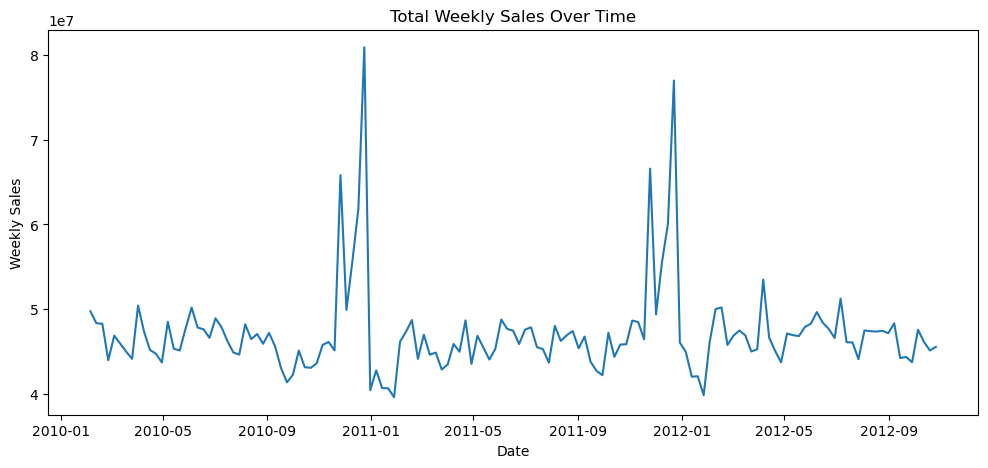

In [39]:
#sales by date joining
weekly_trend=(df_final.groupby('Date')['Weekly_Sales'].sum().reset_index())
#ploting the total walmart weekly sales
plt.figure(figsize=(12,5))
plt.plot(weekly_trend['Date'],weekly_trend['Weekly_Sales'])
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()


In [40]:
#comparing the average sales in hokidays
holiday_sales=(df_final.groupby('IsHoliday')['Weekly_Sales'].mean().reset_index())
holiday_sales

,IsHoliday,Weekly_Sales
0,False,15901.445069
1,True,17035.823187


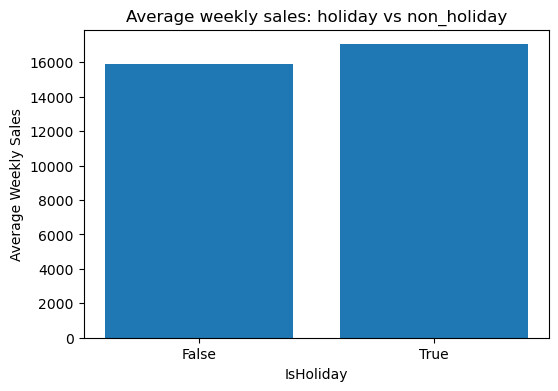

In [41]:
#ploting the comparision using bar chart
plt.figure(figsize=(6,4))
plt.bar(holiday_sales['IsHoliday'].astype(str),holiday_sales['Weekly_Sales'])
plt.title('Average weekly sales: holiday vs non_holiday')
plt.xlabel('IsHoliday')
plt.ylabel('Average Weekly Sales')
plt.show()


In [42]:
#average sales by store size
size_sales=(df_final.groupby('Size')['Weekly_Sales'].mean().reset_index())
size_sales.head()


,Size,Weekly_Sales
0,34875,5053.415813
1,37392,6373.033983
2,39690,8262.936295
3,39910,8297.715353
4,41062,13415.114118


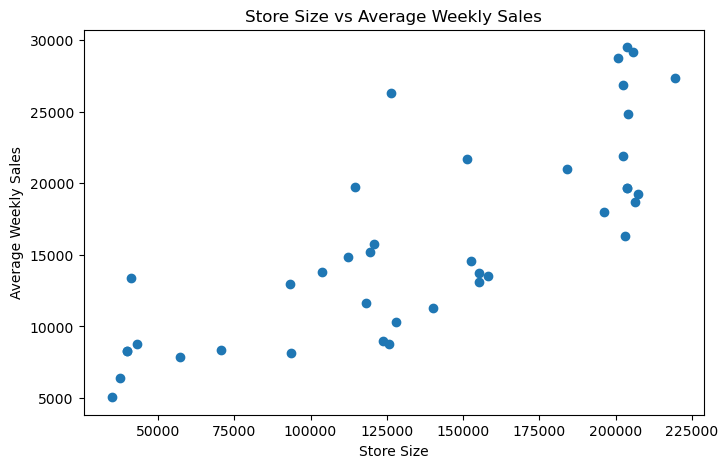

In [43]:
#ploting the size vs sales using scatter plot
plt.figure(figsize=(8,5))
plt.scatter(size_sales['Size'],size_sales['Weekly_Sales'])
plt.title('Store Size vs Average Weekly Sales')
plt.xlabel('Store Size')
plt.ylabel('Average Weekly Sales')
plt.show()

In [44]:
type_sales=(df_final.groupby('Type')['Weekly_Sales'].mean().reset_index())
type_sales

,Type,Weekly_Sales
0,A,20099.568043
1,B,12237.075977
2,C,9519.532538


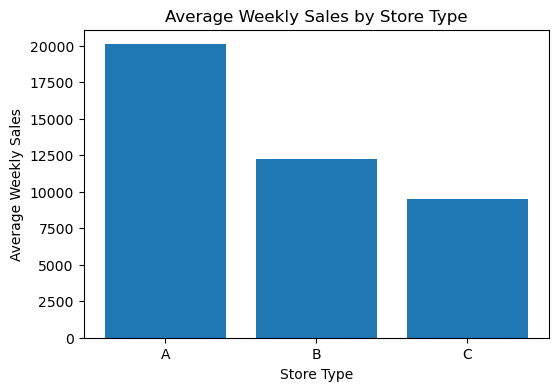

In [45]:
#ploting the type wise sales using barchart
plt.figure(figsize=(6,4))
plt.bar(type_sales['Type'], type_sales['Weekly_Sales'])
plt.title('Average Weekly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Weekly Sales')
plt.show()

In [46]:
#trying to do feature engineering


#making a dupilicate of df_final
df_fe=df_final.copy()

In [47]:
df_fe['Year']=df_fe['Date'].dt.year
df_fe['Month']=df_fe['Date'].dt.month
df_fe['Week']=df_fe['Date'].dt.isocalendar().week.astype(int)

In [48]:
df_fe[['Date','Year','Month','Week']].head()


,Date,Year,Month,Week
0,2010-02-05,2010,2,5
1,2010-02-05,2010,2,5
2,2010-02-05,2010,2,5
3,2010-02-05,2010,2,5
4,2010-02-05,2010,2,5


In [49]:
#models cant use text directly so changing a,b,c to 3,2,1
df_fe['Store_Type']=df_fe['Type'].map({'A':3,'B':2,'C':1})

In [50]:
#log transform makes data more learnable and readable
df_fe['Log_Store_Size']=np.log1p(df_fe['Size'])

In [51]:
#veriring the new columns we added
df_fe[['Type','Store_Type','Size','Log_Store_Size']].head()


,Type,Store_Type,Size,Log_Store_Size
0,A,3,151315,11.927126
1,B,2,93638,11.447202
2,B,2,93638,11.447202
3,B,2,93638,11.447202
4,B,2,93638,11.447202


In [52]:
#using lag features for using past sales to predict future sales
df_fe=df_fe.sort_values(['Store','Dept','Date'])
df_fe['Sales_Lag_1']=(df_fe.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1))
df_fe[['Store','Dept','Date','Weekly_Sales','Sales_Lag_1']].head(10)



,Store,Dept,Date,Weekly_Sales,Sales_Lag_1
0,1,1,2010-02-05,24924.50,NaN
5747,1,1,2010-02-12,46039.49,24924.50
6829,1,1,2010-02-19,41595.55,46039.49
11698,1,1,2010-02-26,19403.54,41595.55
12681,1,1,2010-03-05,21827.90,19403.54
14978,1,1,2010-03-12,21043.39,21827.90
20458,1,1,2010-03-19,22136.64,21043.39
20906,1,1,2010-03-26,26229.21,22136.64
26447,1,1,2010-04-02,57258.43,26229.21
28687,1,1,2010-04-09,42960.91,57258.43


In [53]:
df_fe['Sales_Lag_2']=(df_fe.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(2))
df_fe[['Store','Dept','Date','Weekly_Sales','Sales_Lag_1','Sales_Lag_2']].head(10)

,Store,Dept,Date,Weekly_Sales,Sales_Lag_1,Sales_Lag_2
0,1,1,2010-02-05,24924.50,NaN,NaN
5747,1,1,2010-02-12,46039.49,24924.50,NaN
6829,1,1,2010-02-19,41595.55,46039.49,24924.50
11698,1,1,2010-02-26,19403.54,41595.55,46039.49
12681,1,1,2010-03-05,21827.90,19403.54,41595.55
14978,1,1,2010-03-12,21043.39,21827.90,19403.54
20458,1,1,2010-03-19,22136.64,21043.39,21827.90
20906,1,1,2010-03-26,26229.21,22136.64,21043.39
26447,1,1,2010-04-02,57258.43,26229.21,22136.64
28687,1,1,2010-04-09,42960.91,57258.43,26229.21


In [54]:
#using rolling average features to look at overall recent trend like average sales over last 3 weeks 
df_fe['Sales_Rolling_3']=(df_fe.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).rolling(window=3).mean())
#shift(1) used to prevents data leakage
#(window=3) last 3 weeks average

In [55]:
#using rolling average to last 5 week rolling average
df_fe['Sales_Rolling_5']=(df_fe.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).rolling(window=5).mean())

In [56]:
df_fe[['Store','Dept','Date','Weekly_Sales','Sales_Lag_1','Sales_Lag_2','Sales_Rolling_3','Sales_Rolling_5']].head(12)
df_fe.shape

(421570, 25)

In [57]:
#droping rows with insufficient history filling them would create noise 
df_model=df_fe.dropna().reset_index(drop=True)


In [58]:
df_model.isnull().sum

<bound method DataFrame.sum of        Store   Dept   Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      False  False  False         False      False        False       False   
1      False  False  False         False      False        False       False   
2      False  False  False         False      False        False       False   
3      False  False  False         False      False        False       False   
4      False  False  False         False      False        False       False   
...      ...    ...    ...           ...        ...          ...         ...   
96870  False  False  False         False      False        False       False   
96871  False  False  False         False      False        False       False   
96872  False  False  False         False      False        False       False   
96873  False  False  False         False      False        False       False   
96874  False  False  False         False      False        False       False   

       3

In [59]:
#modeling 
#defining target and feature set
target='Weekly_Sales'
features = [
    'Year','Month','Week',
    'IsHoliday',
    'Temperature','Fuel_Price','CPI','Unemployment',
    'Store_Type','Log_Store_Size',
    'Sales_Lag_1','Sales_Lag_2',
    'Sales_Rolling_3','Sales_Rolling_5'
]

In [60]:
#modeling
#model 1 linear regression for building a base line 

In [61]:
x=df_model[features]
y=df_model[target]

#time-based train_test_split
split_date='2012-01-01'

x_train=x[df_model['Date']<split_date]
x_test=x[df_model['Date']>=split_date]

y_train=y[df_model['Date']<split_date]
y_test=y[df_model['Date']>=split_date]

In [62]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [63]:
#train linear regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train_scaled,y_train)

LinearRegression()

In [64]:
#making predictions
y_pred_lr=lr.predict(x_test_scaled)


In [65]:
#evaluate model perfomance using rmse mae r2
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

rmse_lr=np.sqrt(mean_squared_error(y_test,y_pred_lr))
mae_lr=mean_absolute_error(y_test,y_pred_lr)
r2_lr=r2_score(y_test,y_pred_lr)

rmse_lr, mae_lr, r2_lr


(np.float64(14567.172655677889), 12615.51491139127, 0.6096164104609241)

In [66]:
#lasso regression 
#train lasso with cross-validation
from sklearn.linear_model import LassoCV
lasso=LassoCV(cv=5,random_state=42)
lasso.fit(x_train_scaled,y_train)

LassoCV(cv=5, random_state=42)

In [67]:
y_pred_lasso=lasso.predict(x_test_scaled)

In [68]:
rmse_lasso=np.sqrt(mean_squared_error(y_test,y_pred_lasso))
mae_lasso=mean_absolute_error(y_test,y_pred_lasso)
r2_lasso=r2_score(y_test,y_pred_lasso)

rmse_lasso,mae_lasso,r2_lasso

(np.float64(14258.065084405664), 12336.963729547064, 0.6260080939040475)

In [69]:
#model3
#using random forest 
from sklearn.ensemble import RandomForestRegressor
rf =RandomForestRegressor(n_estimators=300,max_depth=12,random_state=42,min_samples_leaf=5)
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=12, min_samples_leaf=5, n_estimators=300,
                      random_state=42)

In [70]:
y_pred_rf=rf.predict(x_test)

In [71]:
rmse_rf=np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf=mean_absolute_error(y_test, y_pred_rf)
r2_rf=r2_score(y_test, y_pred_rf)

rmse_rf,mae_rf,r2_rf

(np.float64(6664.825122210683), 2902.3889502153756, 0.9182818484041739)

In [72]:

feature_importance = pd.Series(rf.feature_importances_,index=features).sort_values(ascending=False)

feature_importance


Sales_Rolling_5    0.685603
Sales_Rolling_3    0.180981
Week               0.045052
Sales_Lag_1        0.039319
Sales_Lag_2        0.018513
IsHoliday          0.011961
Temperature        0.005311
Fuel_Price         0.003754
Log_Store_Size     0.003716
Unemployment       0.002665
CPI                0.002597
Store_Type         0.000273
Month              0.000255
Year               0.000000
dtype: float64

<Axes: title={'center': 'Top Feature Importances'}>

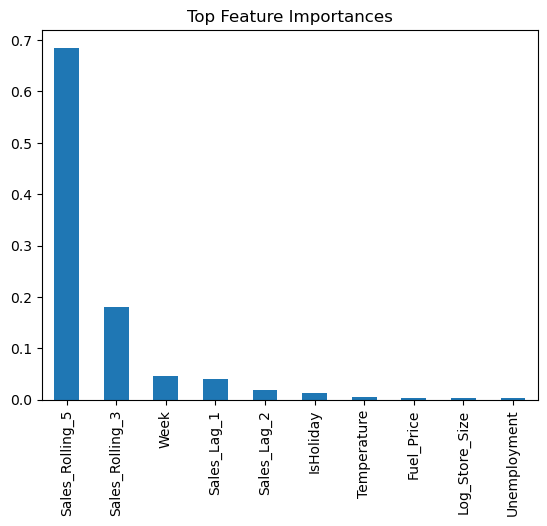

In [73]:
feature_importance.head(10).plot(kind='bar',title='Top Feature Importances')


In [74]:
#trying ot save the predictig data as csv 
#Prepare latest data
latest_data=(df_model.sort_values('Date').groupby(['Store', 'Dept']).tail(1).reset_index(drop=True))
latest_data

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,3/1/01,3/2/01,3/3/01,...,Size,Year,Month,Week,Store_Type,Log_Store_Size,Sales_Lag_1,Sales_Lag_2,Sales_Rolling_3,Sales_Rolling_5
0,15,45,2011-11-11,19.86,False,47.13,3.719,9727.57,4267.72,617.98,...,123737,2011,11,45,2,11.725922,-19.86,19.86,6.620000,11.916
1,25,51,2011-11-18,7.00,False,46.41,3.530,6165.27,168.82,94.85,...,128107,2011,11,46,2,11.760629,6.50,1.50,2.666667,2.800
2,26,50,2011-11-18,-79.00,False,37.78,3.571,5590.39,226.18,61.08,...,152513,2011,11,46,3,11.935012,777.00,312.00,516.333333,512.400
3,6,45,2011-11-25,11.97,True,62.78,3.236,429.03,171.88,83192.81,...,202505,2011,11,47,3,12.218525,11.97,71.82,35.910000,25.934
4,7,19,2011-12-02,-6.94,False,20.38,3.378,2229.32,6.47,738.42,...,70713,2011,12,48,2,11.166399,10.97,-10.97,26.000000,67.400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3116,35,3,2012-10-26,8319.50,False,58.99,3.882,6221.06,42.48,103.00,...,103681,2012,10,43,2,11.549084,7959.58,8263.79,8494.746667,8806.418
3117,41,97,2012-10-26,20661.76,False,41.80,3.686,4864.30,101.34,250.60,...,196321,2012,10,43,3,12.187511,20912.24,23827.78,22441.996667,21965.850
3118,26,32,2012-10-26,3695.64,False,46.95,3.917,1827.16,35.87,50.00,...,152513,2012,10,43,3,11.935012,2884.04,3581.32,3253.793333,3202.480
3119,45,31,2012-10-26,1903.56,False,58.85,3.882,4018.91,58.08,100.00,...,118221,2012,10,43,2,11.680319,2558.30,2220.76,2223.786667,2138.562


In [75]:
x_latest=latest_data[features]


In [76]:
#prediction using random frorest that has be already trained
latest_data['Predicted_Weekly_Sales']=rf.predict(x_latest)
latest_data['Demand_Change']=(latest_data['Predicted_Weekly_Sales']-latest_data['Weekly_Sales'])
latest_data


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,3/1/01,3/2/01,3/3/01,...,Month,Week,Store_Type,Log_Store_Size,Sales_Lag_1,Sales_Lag_2,Sales_Rolling_3,Sales_Rolling_5,Predicted_Weekly_Sales,Demand_Change
0,15,45,2011-11-11,19.86,False,47.13,3.719,9727.57,4267.72,617.98,...,11,45,2,11.725922,-19.86,19.86,6.620000,11.916,29.650065,9.790065
1,25,51,2011-11-18,7.00,False,46.41,3.530,6165.27,168.82,94.85,...,11,46,2,11.760629,6.50,1.50,2.666667,2.800,28.950748,21.950748
2,26,50,2011-11-18,-79.00,False,37.78,3.571,5590.39,226.18,61.08,...,11,46,3,11.935012,777.00,312.00,516.333333,512.400,749.030519,828.030519
3,6,45,2011-11-25,11.97,True,62.78,3.236,429.03,171.88,83192.81,...,11,47,3,12.218525,11.97,71.82,35.910000,25.934,41.992553,30.022553
4,7,19,2011-12-02,-6.94,False,20.38,3.378,2229.32,6.47,738.42,...,12,48,2,11.166399,10.97,-10.97,26.000000,67.400,51.292821,58.232821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3116,35,3,2012-10-26,8319.50,False,58.99,3.882,6221.06,42.48,103.00,...,10,43,2,11.549084,7959.58,8263.79,8494.746667,8806.418,9333.523622,1014.023622
3117,41,97,2012-10-26,20661.76,False,41.80,3.686,4864.30,101.34,250.60,...,10,43,3,12.187511,20912.24,23827.78,22441.996667,21965.850,21826.429365,1164.669365
3118,26,32,2012-10-26,3695.64,False,46.95,3.917,1827.16,35.87,50.00,...,10,43,3,11.935012,2884.04,3581.32,3253.793333,3202.480,3089.060185,-606.579815
3119,45,31,2012-10-26,1903.56,False,58.85,3.882,4018.91,58.08,100.00,...,10,43,2,11.680319,2558.30,2220.76,2223.786667,2138.562,2386.120304,482.560304


In [77]:
prediction_output = latest_data[
    [
        'Store',
        'Dept',
        'Date',
        'Weekly_Sales',
        'Predicted_Weekly_Sales',
        'Demand_Change'
    ]
]
prediction_output

,Store,Dept,Date,Weekly_Sales,Predicted_Weekly_Sales,Demand_Change
0,15,45,2011-11-11,19.86,29.650065,9.790065
1,25,51,2011-11-18,7.00,28.950748,21.950748
2,26,50,2011-11-18,-79.00,749.030519,828.030519
3,6,45,2011-11-25,11.97,41.992553,30.022553
4,7,19,2011-12-02,-6.94,51.292821,58.232821
...,...,...,...,...,...,...
3116,35,3,2012-10-26,8319.50,9333.523622,1014.023622
3117,41,97,2012-10-26,20661.76,21826.429365,1164.669365
3118,26,32,2012-10-26,3695.64,3089.060185,-606.579815
3119,45,31,2012-10-26,1903.56,2386.120304,482.560304


In [78]:
prediction_output.to_csv('walmart_next_week_sales_prediction.csv',index=False)


array([28150.34094921])